In [66]:
!pip install rdkit pubchempy -q
!wget -q https://github.com/grimme-lab/xtb/releases/download/v6.6.1/xtb-6.6.1-linux-x86_64.tar.xz
!tar -xf xtb-6.6.1-linux-x86_64.tar.xz

import os, re
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
import pubchempy as pcp

os.environ["PATH"] += ":/content/xtb-6.6.1/bin"
print("Setup complete")

Setup complete


In [68]:
pfas_smiles = {
    "TFA":   "OC(=O)C(F)(F)F",
    "PFMS":  "OS(=O)(=O)C(F)(F)F",
    "PFPrA": "OC(=O)C(F)(F)C(F)(F)F",
    "PFPrS": "OS(=O)(=O)C(F)(F)C(F)(F)F",
    "PFBA":  "OC(=O)C(F)(F)C(F)(F)C(F)(F)F",
    "PFBS":  "OS(=O)(=O)C(F)(F)C(F)(F)C(F)(F)F",
    "PFOA":  "OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F",
    "PFOS":  "OS(=O)(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F",
}

for name, smi in pfas_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol)
    Chem.MolToXYZFile(mol, f"{name}.xyz")

pcp.download('SDF', 'coronene.sdf', 'coronene', 'name', record_type='3d', overwrite=True)
mol = Chem.MolFromMolFile('coronene.sdf', removeHs=False)
Chem.MolToXYZFile(mol, 'coronene.xyz')
print("All structures generated")

All structures generated


In [69]:
molecules = list(pfas_smiles.keys()) + ["coronene"]

for mol in molecules:
    !xtb {mol}.xyz --opt --alpb water 2>/dev/null
    !cp xtbopt.xyz {mol}_opt.xyz
    print(f"Optimized: {mol}")

print("All optimizations done")

Streaming output truncated to the last 5000 lines.
   4    -50.5044300 -0.283546E-05  0.115E-02    5.04       2.3  T
   5    -50.5044303 -0.339421E-06  0.326E-03    5.04       8.2  T
   6    -50.5044303 -0.677610E-08  0.119E-03    5.04      22.5  T
   7    -50.5044303 -0.397679E-08  0.369E-04    5.04      72.4  T
   8    -50.5044303 -0.124594E-09  0.109E-04    5.04     245.1  T
     SCC iter.                  ...        0 min,  0.005 sec
     gradient                   ...        0 min,  0.004 sec
 * total energy  :   -50.3221757 Eh     change       -0.3814179E-02 Eh
   gradient norm :     0.0146415 Eh/α   predicted    -0.3644048E-02 (  -4.46%)
   displ. norm   :     0.0907713 α      lambda       -0.5370236E-03
   maximum displ.:     0.0564018 α      in ANC's #1, #15, #4, ...

........................................................................
.............................. CYCLE    4 ..............................
..................................................................

In [70]:
energies = {}

for mol in molecules:
    with open(f"{mol}_opt.xyz") as f:
        lines = f.readlines()
    match = re.search(r'[-\d.]+', lines[1])
    energies[mol] = float(match.group())
    print(f"{mol}: {energies[mol]:.6f} Eh")

print("Energies extracted")

TFA: -27.127202 Eh
PFMS: -32.295566 Eh
PFPrA: -38.726726 Eh
PFPrS: -43.896110 Eh
PFBA: -50.322847 Eh
PFBS: -55.493287 Eh
PFOA: -85.111868 Eh
PFOS: -90.281506 Eh
coronene: -57.605652 Eh
Energies extracted


In [71]:
def combine_xyz_oriented(file1, file2, output, offset_z=3.5, rotate_x=0, rotate_z=0):
    with open(file1) as f: lines1 = f.readlines()
    with open(file2) as f: lines2 = f.readlines()

    coords, symbols = [], []
    for line in lines1[2:]:
        parts = line.split()
        if len(parts) == 4:
            symbols.append(parts[0])
            coords.append([float(parts[1]), float(parts[2]), float(parts[3])])

    coords = np.array(coords)
    rx, rz = np.radians(rotate_x), np.radians(rotate_z)
    Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
    Rz = np.array([[np.cos(rz),-np.sin(rz),0],[np.sin(rz),np.cos(rz),0],[0,0,1]])
    coords = coords @ Rx.T @ Rz.T
    coords[:,2] += offset_z

    with open(output, 'w') as f:
        f.write(f"{len(coords)+len(lines2[2:])}\nPFAS on coronene\n")
        for sym, c in zip(symbols, coords):
            f.write(f"{sym}  {c[0]:.6f}  {c[1]:.6f}  {c[2]:.6f}\n")
        f.writelines(lines2[2:])

orientations = [(0,0), (45,0), (90,45)]
pfas_list = list(pfas_smiles.keys())

for name in pfas_list:
    for i, (rx, rz) in enumerate(orientations, 1):
        combine_xyz_oriented(f"{name}_opt.xyz", "coronene_opt.xyz",
                             f"{name}_c_or{i}.xyz", rotate_x=rx, rotate_z=rz)
print("All complexes built")

All complexes built


In [72]:
for name in pfas_list:
    for i in range(1, 4):
        !xtb {name}_c_or{i}.xyz --opt --alpb water 2>/dev/null
        !cp xtbopt.xyz {name}_c_or{i}_opt.xyz
    print(f"Done: {name}")

print("All complexes optimized")

Streaming output truncated to the last 5000 lines.
   6   -149.3276005 -0.361431E-07  0.550E-04    2.68      23.5  T
   7   -149.3276005 -0.142987E-08  0.277E-04    2.68      46.7  T
     SCC iter.                  ...        0 min,  0.073 sec
     gradient                   ...        0 min,  0.050 sec
 * total energy  :  -147.8966047 Eh     change       -0.2355116E-02 Eh
   gradient norm :     0.0154488 Eh/α   predicted    -0.2000925E-02 ( -15.04%)
   displ. norm   :     0.5279511 α      lambda       -0.2123116E-02
   maximum displ.:     0.3003460 α      in ANC's #10, #6, #21, ...

........................................................................
.............................. CYCLE   13 ..............................
........................................................................

 iter      E             dE          RMSdq      gap      omega  full diag
   1   -149.3275935 -0.149328E+03  0.970E-02    2.68       0.0  T
   2   -149.3275962 -0.275132E-05  0.572E-02    2

In [73]:
adsorption_energies = {}

for name in pfas_list:
    complex_energies = []
    for i in range(1, 4):
        with open(f"{name}_c_or{i}_opt.xyz") as f:
            lines = f.readlines()
        match = re.search(r'[-\d.]+', lines[1])
        if match:
            complex_energies.append(float(match.group()))

    best = min(complex_energies)
    E_ads = (best - energies[name] - energies["coronene"]) * 627.509
    adsorption_energies[name] = round(E_ads, 2)
    print(f"{name}: {adsorption_energies[name]} kcal/mol")

print("Adsorption energies done")

TFA: -5.98 kcal/mol
PFMS: -7.52 kcal/mol
PFPrA: -7.09 kcal/mol
PFPrS: -7.71 kcal/mol
PFBA: -6.96 kcal/mol
PFBS: -9.28 kcal/mol
PFOA: -7.82 kcal/mol
PFOS: -9.89 kcal/mol
Adsorption energies done


In [74]:
pfas_atom_counts = {
    "TFA":8, "PFMS":9, "PFPrA":11, "PFPrS":12,
    "PFBA":14, "PFBS":15, "PFOA":20, "PFOS":21
}

for name in pfas_list:
    !xtb {name}_c_or1_opt.xyz --alpb water --pop > {name}_charges.txt 2>&1

charge_transfer = {}
for name, n_atoms in pfas_atom_counts.items():
    with open(f"{name}_charges.txt") as f:
        lines = f.readlines()
    start = next(i+1 for i,l in enumerate(lines) if "covCN" in l)
    charges = []
    for line in lines[start:start+200]:
        parts = line.split()
        if len(parts) >= 6:
            try:
                int(parts[0]); int(parts[1])
                charges.append(float(parts[4]))
            except: pass
    q_pfas = sum(charges[:n_atoms])
    charge_transfer[name] = round(-q_pfas, 4)
    print(f"{name}: {charge_transfer[name]:+.4f} e")

print("Charge transfer done")

TFA: +0.0010 e
PFMS: +0.0010 e
PFPrA: +0.0000 e
PFPrS: -0.0000 e
PFBA: -0.0000 e
PFBS: +0.0020 e
PFOA: +0.1620 e
PFOS: +0.1830 e
Charge transfer done


In [75]:
print(f"{'Compound':<10} {'Chain':<8} {'Group':<12} {'Eads (kcal/mol)':<18} {'Charge Transfer (e)'}")
print("-" * 60)
meta = {
    "TFA":  ("C2","Carboxylate"), "PFMS": ("C1","Sulfonate"),
    "PFPrA":("C3","Carboxylate"), "PFPrS":("C3","Sulfonate"),
    "PFBA": ("C4","Carboxylate"), "PFBS": ("C4","Sulfonate"),
    "PFOA": ("C8","Carboxylate"), "PFOS": ("C8","Sulfonate"),
}
for name in pfas_list:
    chain, group = meta[name]
    print(f"{name:<10} {chain:<8} {group:<12} {adsorption_energies[name]:<18} {charge_transfer[name]:+.4f}")

Compound   Chain    Group        Eads (kcal/mol)    Charge Transfer (e)
------------------------------------------------------------
TFA        C2       Carboxylate  -5.98              +0.0010
PFMS       C1       Sulfonate    -7.52              +0.0010
PFPrA      C3       Carboxylate  -7.09              +0.0000
PFPrS      C3       Sulfonate    -7.71              -0.0000
PFBA       C4       Carboxylate  -6.96              -0.0000
PFBS       C4       Sulfonate    -9.28              +0.0020
PFOA       C8       Carboxylate  -7.82              +0.1620
PFOS       C8       Sulfonate    -9.89              +0.1830


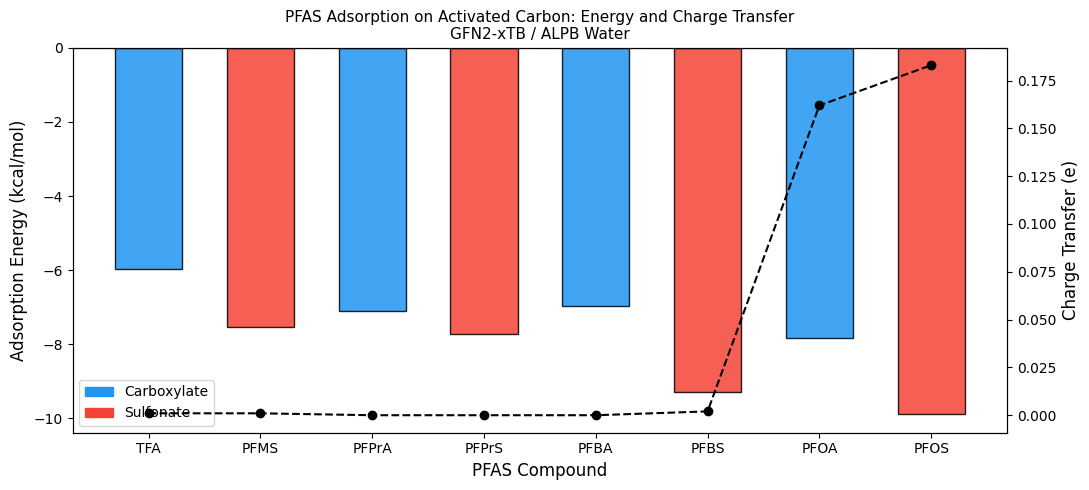

In [76]:
names = pfas_list
eads = [adsorption_energies[n] for n in names]
ct = [charge_transfer[n] for n in names]
colors = ['#2196F3','#F44336'] * 4

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(names, eads, color=colors, edgecolor='black', width=0.6, alpha=0.85)
ax1.set_ylabel('Adsorption Energy (kcal/mol)', fontsize=12)
ax1.set_xlabel('PFAS Compound', fontsize=12)
ax1.axhline(0, color='black', linewidth=0.8)

ax2 = ax1.twinx()
ax2.plot(names, ct, 'ko--', linewidth=1.5, markersize=6)
ax2.set_ylabel('Charge Transfer (e)', fontsize=12)

ax1.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2196F3', label='Carboxylate'),
    plt.Rectangle((0,0),1,1, color='#F44336', label='Sulfonate'),
], fontsize=10, loc='lower left')

plt.title('PFAS Adsorption on Activated Carbon: Energy and Charge Transfer\nGFN2-xTB / ALPB Water', fontsize=11)
plt.tight_layout()
plt.savefig('final_figure.png', dpi=150)
plt.show()

In [77]:
# Oxidized coronene: coronene with -COOH and -OH substituents
ox_coronene_smiles = "OC(=O)c1ccc2ccc3ccc4ccc5ccc6c(O)cccc6c5c4c3c2c1"

mol = Chem.MolFromSmiles(ox_coronene_smiles)
if mol is None:
    print("SMILES failed")
else:
    mol = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    print("Embed result:", result)

Embed result: -1


In [78]:
ox_coronene_smiles = "Oc1ccc2ccc3ccc4ccc5ccc6ccccc6c5c4c3c2c1"

mol = Chem.MolFromSmiles(ox_coronene_smiles)
if mol is None:
    print("SMILES failed")
else:
    mol = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol, randomSeed=42)
    print("Embed result:", result)

Embed result: -1


In [79]:
# Read optimized coronene
with open("coronene_opt.xyz") as f:
    lines = f.readlines()

print(f"Total atoms: {lines[0].strip()}")
print("Last 5 lines:")
for line in lines[-5:]:
    print(line.strip())

Total atoms: 36
Last 5 lines:
H            4.34289905797657        1.92989652610329       -0.00002428653356
H            3.84273813598335       -2.79609405279580        0.00003486851488
H           -4.72561016648567        0.50362900117942       -0.00005517898349
H            0.50019074593992        4.72602595537358        0.00009839974171
H            4.72562677924339       -0.50360632424816       -0.00003314202310


In [80]:
with open("coronene_opt.xyz") as f:
    lines = f.readlines()

# Replace last H atom with O, and add new H for the OH group
# Get the last H coordinates
last_h = lines[-1].split()
hx, hy, hz = float(last_h[1]), float(last_h[2]), float(last_h[3])

# Place O where H was (slightly further out)
ox = hx * 1.4
oy = hy * 1.4
oz = hz

# Place new H further out from O
hx2 = hx * 1.9
hy2 = hy * 1.9
hz2 = hz

# Build new xyz
new_atoms = lines[2:-1]  # all atoms except last H
new_atoms.append(f"O  {ox:.6f}  {oy:.6f}  {oz:.6f}\n")
new_atoms.append(f"H  {hx2:.6f}  {hy2:.6f}  {hz2:.6f}\n")

total = len(new_atoms)
with open("ox_coronene.xyz", "w") as f:
    f.write(f"{total}\nOxidized coronene\n")
    f.writelines(new_atoms)

print("Done — ox_coronene.xyz written with", total, "atoms")

Done — ox_coronene.xyz written with 37 atoms


In [81]:
!xtb ox_coronene.xyz --opt
!cp xtbopt.xyz ox_coronene_opt.xyz

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [82]:
energies["ox_coronene"] = -61.253347468037
print("ox_coronene energy stored:", energies["ox_coronene"])

ox_coronene energy stored: -61.253347468037


In [83]:
for name in pfas_list:
    for i, (rx, rz) in enumerate(orientations, 1):
        combine_xyz_oriented(f"{name}_opt.xyz", "ox_coronene_opt.xyz",
                             f"{name}_oxc_or{i}.xyz", rotate_x=rx, rotate_z=rz)
    print(f"Built: {name}")

print("All oxidized complexes built")

Built: TFA
Built: PFMS
Built: PFPrA
Built: PFPrS
Built: PFBA
Built: PFBS
Built: PFOA
Built: PFOS
All oxidized complexes built


In [84]:
for name in pfas_list:
    for i in range(1, 4):
        !xtb {name}_oxc_or{i}.xyz --opt --alpb water 2>/dev/null
        !cp xtbopt.xyz {name}_oxc_or{i}_opt.xyz
    print(f"Done: {name}")

print("All oxidized complexes optimized")

Streaming output truncated to the last 5000 lines.
  13   -239.8477924 -0.452393E-06  0.351E-04    0.01      31.1  T
  14   -239.8477923  0.287047E-07  0.606E-04    0.01      18.0  T
     SCC iter.                  ...        0 min,  0.374 sec
     gradient                   ...        0 min,  0.142 sec
 * total energy  :  -238.1506837 Eh     change       -0.1194409E-02 Eh
   gradient norm :     0.0226892 Eh/α   predicted    -0.1178296E-02 (  -1.35%)
   displ. norm   :     0.4295303 α      lambda       -0.1884284E-02
   maximum displ.:     0.1411955 α      in ANC's #31, #1, #29, ...

........................................................................
.............................. CYCLE   91 ..............................
........................................................................

 iter      E             dE          RMSdq      gap      omega  full diag
   1   -239.7592182 -0.239759E+03  0.101E+00    0.03       0.0  T
   2   -239.5045656  0.254653E+00  0.191E+00    1

In [85]:
adsorption_energies_ox = {}

for name in pfas_list:
    complex_energies = []
    for i in range(1, 4):
        with open(f"{name}_oxc_or{i}_opt.xyz") as f:
            lines = f.readlines()
        match = re.search(r'[-\d.]+', lines[1])
        if match:
            complex_energies.append(float(match.group()))

    best = min(complex_energies)
    E_ads = (best - energies[name] - energies["ox_coronene"]) * 627.509
    adsorption_energies_ox[name] = round(E_ads, 2)
    print(f"{name}: {adsorption_energies_ox[name]} kcal/mol")

print("Done")

TFA: -54357.65 kcal/mol
PFMS: -54449.55 kcal/mol
PFPrA: -54367.45 kcal/mol
PFPrS: -54336.5 kcal/mol
PFBA: -54349.97 kcal/mol
PFBS: -54419.89 kcal/mol
PFOA: -54364.92 kcal/mol
PFOS: -54426.5 kcal/mol
Done


In [86]:
with open("TFA_oxc_or1_opt.xyz") as f:
    lines = f.readlines()

print("Line 0:", lines[0].strip())
print("Line 1:", lines[1].strip())

Line 0: 68
Line 1: energy: -175.005044026769 gnorm: 0.011343313208 xtb: 6.6.1 (8d0f1dd)


In [87]:
adsorption_energies_ox = {}

for name in pfas_list:
    complex_energies = []
    for i in range(1, 4):
        with open(f"{name}_oxc_or{i}_opt.xyz") as f:
            lines = f.readlines()
        # Extract energy specifically after "energy:" keyword
        match = re.search(r'energy:\s*([-\d.]+)', lines[1])
        if match:
            complex_energies.append(float(match.group(1)))

    best = min(complex_energies)
    E_ads = (best - energies[name] - energies["ox_coronene"]) * 627.509
    adsorption_energies_ox[name] = round(E_ads, 2)
    print(f"{name}: {adsorption_energies_ox[name]} kcal/mol")

print("Done")

TFA: -54357.65 kcal/mol
PFMS: -54449.55 kcal/mol
PFPrA: -54367.45 kcal/mol
PFPrS: -54336.5 kcal/mol
PFBA: -54349.97 kcal/mol
PFBS: -54419.89 kcal/mol
PFOA: -54364.92 kcal/mol
PFOS: -54426.5 kcal/mol
Done


In [88]:
print("ox_coronene energy:", energies["ox_coronene"])
print("TFA energy:", energies["TFA"])

# Manual check for TFA
E_complex = -175.005044026769
E_TFA = energies["TFA"]
E_ox = energies["ox_coronene"]

print(f"\nE_complex: {E_complex}")
print(f"E_TFA:     {E_TFA}")
print(f"E_ox:      {E_ox}")
print(f"Sum TFA+ox: {E_TFA + E_ox}")
print(f"Difference: {E_complex - E_TFA - E_ox}")

ox_coronene energy: -61.253347468037
TFA energy: -27.127201889508

E_complex: -175.005044026769
E_TFA:     -27.127201889508
E_ox:      -61.253347468037
Sum TFA+ox: -88.380549357545
Difference: -86.62449466922402


In [89]:
with open("TFA_oxc_or1_opt.xyz") as f:
    lines = f.readlines()

print("Atom count:", lines[0].strip())
print("Line 1:", lines[1].strip())
print("First 3 atoms:")
for line in lines[2:5]:
    print(line.strip())

Atom count: 68
Line 1: energy: -175.005044026769 gnorm: 0.011343313208 xtb: 6.6.1 (8d0f1dd)
First 3 atoms:
O            1.77752891148045       -0.70463114452813        2.81490079684778
C            0.61839053215291       -0.88136671959480        2.78980262018783
O            0.86175127203444        1.91706096462275        2.99544298651598


In [90]:
with open("ox_coronene_opt.xyz") as f:
    lines = f.readlines()

print("Atom count:", lines[0].strip())
print("Line 1:", lines[1].strip())

Atom count: 60
Line 1: energy: -147.902444929989 gnorm: 0.000734546386 xtb: 6.6.1 (8d0f1dd)


In [91]:
# Rebuild oxidized coronene from scratch
with open("coronene_opt.xyz") as f:
    lines = f.readlines()

print("Coronene atoms:", lines[0].strip())
print("Coronene energy:", lines[1].strip())

Coronene atoms: 36
Coronene energy: energy: -57.605651547570 gnorm: 0.000073619900 xtb: 6.6.1 (8d0f1dd)


In [92]:
with open("coronene_opt.xyz") as f:
    lines = f.readlines()

last_h = lines[-1].split()
hx, hy, hz = float(last_h[1]), float(last_h[2]), float(last_h[3])
ox, oy, oz = hx*1.4, hy*1.4, hz
hx2, hy2, hz2 = hx*1.9, hy*1.9, hz

new_atoms = lines[2:-1]
new_atoms.append(f"O  {ox:.6f}  {oy:.6f}  {oz:.6f}\n")
new_atoms.append(f"H  {hx2:.6f}  {hy2:.6f}  {hz2:.6f}\n")

with open("ox_coronene_clean.xyz", "w") as f:
    f.write(f"{len(new_atoms)}\nOxidized coronene\n")
    f.writelines(new_atoms)

print("Atoms:", len(new_atoms))

Atoms: 37


In [93]:
!xtb ox_coronene_clean.xyz --opt 2>/dev/null
!cp xtbopt.xyz ox_coronene_clean_opt.xyz

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [94]:
with open("ox_coronene_clean_opt.xyz") as f:
    lines = f.readlines()
print("Atoms:", lines[0].strip())
print("Energy:", lines[1].strip())

Atoms: 84
Energy: energy: -238.269070616097 gnorm: 0.000631825632 xtb: 6.6.1 (8d0f1dd)


In [95]:
with open("ox_coronene_clean_opt.xyz") as f:
    content = f.read()

# Split into individual xyz blocks
blocks = []
lines = content.strip().split('\n')
i = 0
while i < len(lines):
    try:
        n_atoms = int(lines[i].strip())
        block = lines[i:i+n_atoms+2]
        blocks.append(block)
        i += n_atoms + 2
    except:
        i += 1

print(f"Found {len(blocks)} structures")
print(f"Last structure atoms: {blocks[-1][0]}")
print(f"Last structure energy: {blocks[-1][1]}")

# Save last (optimized) structure
with open("ox_coronene_final.xyz", "w") as f:
    f.write('\n'.join(blocks[-1]) + '\n')
print("Saved ox_coronene_final.xyz")

Found 1 structures
Last structure atoms: 84
Last structure energy:  energy: -238.269070616097 gnorm: 0.000631825632 xtb: 6.6.1 (8d0f1dd)
Saved ox_coronene_final.xyz


In [96]:
with open("ox_coronene_clean.xyz") as f:
    lines = f.readlines()

print("Total lines:", len(lines))
print("Line 0:", lines[0].strip())
print("Line 1:", lines[1].strip())
print("Last 3 lines:")
for line in lines[-3:]:
    print(line.strip())

Total lines: 39
Line 0: 37
Line 1: Oxidized coronene
Last 3 lines:
H            0.50019074593992        4.72602595537358        0.00009839974171
O  6.615877  -0.705049  -0.000033
H  8.978691  -0.956852  -0.000033


In [97]:
!rm -f xtbrestart xtbopt.xyz
!xtb ox_coronene_clean.xyz --opt 2>/dev/null

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [98]:
!head -3 xtbopt.xyz

head: cannot open 'xtbopt.xyz' for reading: No such file or directory


In [99]:
!xtb ox_coronene_clean.xyz --opt

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [100]:
!xtb ox_coronene_clean.xyz --opt --alpb water --etemp 500 2>/dev/null
!ls xtbopt.xyz

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [101]:
!head -3 xtbopt.xyz

head: cannot open 'xtbopt.xyz' for reading: No such file or directory


In [102]:
!xtb ox_coronene_clean.xyz --gfnff --opt 2>/dev/null
!ls xtbopt.xyz

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [103]:
# 1-hydroxypyrene as oxidized carbon surface proxy
# Well-studied in adsorption literature, available in PubChem
pcp.download('SDF', 'hydroxypyrene.sdf', '1-hydroxypyrene', 'name', record_type='3d', overwrite=True)
mol = Chem.MolFromMolFile('hydroxypyrene.sdf', removeHs=False)
if mol:
    Chem.MolToXYZFile(mol, 'ox_surface.xyz')
    print("Atoms:", mol.GetNumAtoms())
else:
    print("Failed")

Atoms: 27


In [104]:
!xtb ox_surface.xyz --opt --alpb water 2>/dev/null
!cp xtbopt.xyz ox_surface_opt.xyz

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'stahn@M-Bot' on 2023-08-01

   xtb is free software: you can redistribute it and/or modify it under
   the terms of the GNU Lesser General Public License as published by
   the Free Software Foundation, either version 3 of the License, or
   (at your option) any later version.
   
   xtb is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without 

In [105]:
with open("ox_surface_opt.xyz") as f:
    lines = f.readlines()
print("Atoms:", lines[0].strip())
print("Energy:", lines[1].strip())

Atoms: 27
Energy: energy: -43.458899193397 gnorm: 0.000748160892 xtb: 6.6.1 (8d0f1dd)


In [106]:
energies["ox_surface"] = -43.458899193397
print("ox_surface energy stored:", energies["ox_surface"])

ox_surface energy stored: -43.458899193397


In [107]:
for name in pfas_list:
    for i, (rx, rz) in enumerate(orientations, 1):
        combine_xyz_oriented(f"{name}_opt.xyz", "ox_surface_opt.xyz",
                             f"{name}_oxs_or{i}.xyz", rotate_x=rx, rotate_z=rz)
    print(f"Built: {name}")

print("All oxidized surface complexes built")

Built: TFA
Built: PFMS
Built: PFPrA
Built: PFPrS
Built: PFBA
Built: PFBS
Built: PFOA
Built: PFOS
All oxidized surface complexes built


In [108]:
for name in pfas_list:
    for i in range(1, 4):
        !xtb {name}_oxs_or{i}.xyz --opt --alpb water 2>/dev/null
        !cp xtbopt.xyz {name}_oxs_or{i}_opt.xyz
    print(f"Done: {name}")

print("All oxidized surface complexes optimized")

Streaming output truncated to the last 5000 lines.
          :   Hlow (freq-cutoff)         0.1000000E-01      :
          :   Hmax (freq-cutoff)         5.0000000          :
          :   S6 in model hess.         20.0000000          :
          ...................................................

generating ANC from model Hessian ...
Using Lindh-Hessian (1995)
 Shifting diagonal of input Hessian by   9.368871033811427E-003
 Lowest  eigenvalues of input Hessian
    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
    0.010000    0.010861    0.011395    0.011791    0.013691    0.013742
    0.015518    0.016479    0.018004    0.019153    0.019928    0.021952
 Highest eigenvalues
    2.082031    2.150689    2.264113    2.438319    3.159939    3.806886
 

........................................................................
.............................. CYCLE    1 ..............................
.......................................................................

In [109]:
adsorption_energies_ox = {}

for name in pfas_list:
    complex_energies = []
    for i in range(1, 4):
        with open(f"{name}_oxs_or{i}_opt.xyz") as f:
            lines = f.readlines()
        match = re.search(r'energy:\s*([-\d.]+)', lines[1])
        if match:
            complex_energies.append(float(match.group(1)))

    best = min(complex_energies)
    E_ads = (best - energies[name] - energies["ox_surface"]) * 627.509
    adsorption_energies_ox[name] = round(E_ads, 2)
    print(f"{name}: {adsorption_energies_ox[name]} kcal/mol")

print("Done")

TFA: -5.78 kcal/mol
PFMS: -7.44 kcal/mol
PFPrA: -6.54 kcal/mol
PFPrS: -7.1 kcal/mol
PFBA: -6.45 kcal/mol
PFBS: -8.88 kcal/mol
PFOA: -7.32 kcal/mol
PFOS: -8.98 kcal/mol
Done


In [110]:
print(f"{'Compound':<10} {'Chain':<6} {'Group':<12} {'Pristine (kcal/mol)':<22} {'Oxidized (kcal/mol)':<22} {'Difference'}")
print("-" * 80)
for name in pfas_list:
    chain, group = meta[name]
    diff = adsorption_energies_ox[name] - adsorption_energies[name]
    print(f"{name:<10} {chain:<6} {group:<12} {adsorption_energies[name]:<22} {adsorption_energies_ox[name]:<22} {diff:+.2f}")

Compound   Chain  Group        Pristine (kcal/mol)    Oxidized (kcal/mol)    Difference
--------------------------------------------------------------------------------
TFA        C2     Carboxylate  -5.98                  -5.78                  +0.20
PFMS       C1     Sulfonate    -7.52                  -7.44                  +0.08
PFPrA      C3     Carboxylate  -7.09                  -6.54                  +0.55
PFPrS      C3     Sulfonate    -7.71                  -7.1                   +0.61
PFBA       C4     Carboxylate  -6.96                  -6.45                  +0.51
PFBS       C4     Sulfonate    -9.28                  -8.88                  +0.40
PFOA       C8     Carboxylate  -7.82                  -7.32                  +0.50
PFOS       C8     Sulfonate    -9.89                  -8.98                  +0.91


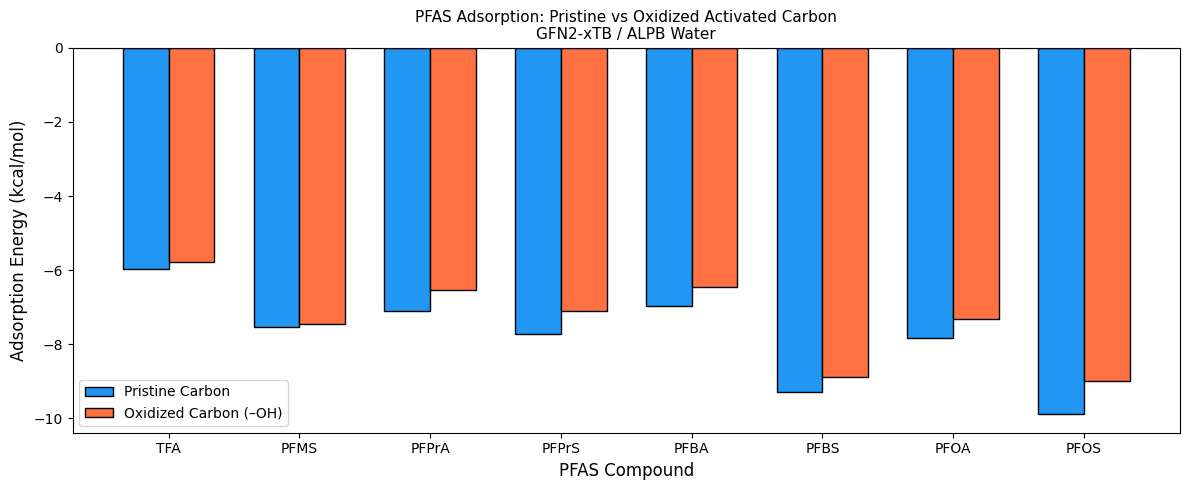

Done


In [111]:
x = np.arange(len(pfas_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12,5))
bars1 = ax.bar(x - width/2, [adsorption_energies[n] for n in pfas_list],
               width, label='Pristine Carbon', color='#2196F3', edgecolor='black')
bars2 = ax.bar(x + width/2, [adsorption_energies_ox[n] for n in pfas_list],
               width, label='Oxidized Carbon (–OH)', color='#FF7043', edgecolor='black')

ax.set_ylabel('Adsorption Energy (kcal/mol)', fontsize=12)
ax.set_xlabel('PFAS Compound', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pfas_list)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(fontsize=10)
ax.set_title('PFAS Adsorption: Pristine vs Oxidized Activated Carbon\nGFN2-xTB / ALPB Water', fontsize=11)

plt.tight_layout()
plt.savefig('pristine_vs_oxidized.png', dpi=150)
plt.show()
print("Done")